# Mouse kidney local inference from precomputed spAlignDE coordinates

This notebook provides a real-data example of the post-alignment inference pipeline. It uses the NL3 normal and IL3 injured mouse-kidney Visium sections. The raw count matrices and tissue-position files come from Zenodo record `17676992`; the package supplies the precomputed `aligned_317` coordinates used for the manuscript analysis.

The analysis proceeds through one continuous handoff:

1. load public expression data and packaged aligned coordinates;
2. match spots by terminal Visium barcode;
3. construct the shared grid and local neighborhoods;
4. estimate stable-gene and density-based mismatch risk;
5. perform gene-specific, locally calibrated Mismatch-aware spatial DE testing; and
6. report grid-level statistics, FDR-adjusted regions, and representative gene maps.

NL3 defines the reference coordinate system and IL3 is the query. This focused tutorial demonstrates the public inference interface rather than reproducing every downstream kidney analysis in the manuscript. By default, it uses the packaged manuscript coordinates; users can instead supply coordinates produced by their own spAlignDE alignment, as described below.

**Fixed-seed reproducibility.** This workflow uses seed `1`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## Optional: use coordinates from your own alignment

No path configuration is required for the example below because the package includes the manuscript alignment coordinates. To continue from a new spAlignDE alignment, place `aligned_coords_NL3.csv` and `aligned_coords_IL3.csv` in one directory and set `SPALIGNDE_ALIGNMENT_DIR` to that directory before running Section 1. Each file must contain one row per retained spot and the columns `barcode`, `x`, and `y`.

```python
import os
os.environ["SPALIGNDE_ALIGNMENT_DIR"] = "/path/to/your/alignment_output"
```

The optional variables `SPALIGNDE_KIDNEY_DATA_DIR` and `SPALIGNDE_TUTORIAL_WORK_DIR` can similarly redirect the raw-data and working directories. If they are not set, the notebook creates a portable working directory under the current directory.


## 1. Install the package and tutorial dependencies

Install the editable package with its optional tutorial dependencies in the active environment:

```bash
python -m pip install -e ".[tutorial]"
```

The notebook imports the packaged manuscript alignment coordinates automatically. Only the public raw Visium files need to be downloaded separately.


In [1]:
from pathlib import Path
import os
import warnings

WORK_DIR = Path(
    os.environ.get(
        "SPALIGNDE_TUTORIAL_WORK_DIR",
        Path.cwd() / "spalignde_kidney_tutorial",
    )
).expanduser().resolve()
DATA_DIR = Path(
    os.environ.get("SPALIGNDE_KIDNEY_DATA_DIR", WORK_DIR / "raw")
).expanduser().resolve()
USER_ALIGNMENT_DIR_VALUE = os.environ.get("SPALIGNDE_ALIGNMENT_DIR")
USER_ALIGNMENT_DIR = (
    Path(USER_ALIGNMENT_DIR_VALUE).expanduser().resolve()
    if USER_ALIGNMENT_DIR_VALUE
    else None
)
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(WORK_DIR / ".matplotlib"),
)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

import urllib.request

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import spAlignDE

WORKFLOW_SEED = 1
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

from spAlignDE import (
    fit_local_de,
    gene_level_acat_pvalue,
    plot_local_result,
    prepare_inference,
)
from spAlignDE.datasets import (
    build_visium_coordinate_table,
    build_visium_inference_table,
    kidney_alignment_metadata,
    load_kidney_aligned_coordinates,
)

print("Raw-data directory:", DATA_DIR)
print(
    "Aligned-coordinate source:",
    USER_ALIGNMENT_DIR if USER_ALIGNMENT_DIR is not None else "packaged manuscript aligned_317",
)
print("Risk-map radius rule: 1.5 x shared-grid spacing")

Raw-data directory: spalignde_kidney_tutorial/raw
Aligned-coordinate source: packaged manuscript aligned_317
Risk-map radius rule: 1.5 x shared-grid spacing


## 2. Obtain the raw Visium files

The source expression data are available from Zenodo record `17676992` under a CC BY 4.0 license. Set `DOWNLOAD_ZENODO=True` to download the four required files into `DATA_DIR`, or place them there manually. The much smaller precomputed alignment-coordinate files are installed with `spalignde` and require no separate download.


In [2]:
DOWNLOAD_ZENODO = False
ZENODO_BASE = "https://zenodo.org/records/17676992/files"
RAW_FILES = [
    "NL3_filtered_feature_bc_matrix.h5",
    "IL3_filtered_feature_bc_matrix.h5",
    "NL3_tissue_positions.csv",
    "IL3_tissue_positions.csv",
]

if DOWNLOAD_ZENODO:
    for filename in RAW_FILES:
        destination = DATA_DIR / filename
        if not destination.exists():
            url = f"{ZENODO_BASE}/{filename}?download=1"
            print("Downloading", url)
            urllib.request.urlretrieve(url, destination)

missing_raw = [name for name in RAW_FILES if not (DATA_DIR / name).exists()]
if missing_raw:
    raise FileNotFoundError(
        "Missing raw Visium files in DATA_DIR: "
        + ", ".join(missing_raw)
        + ". Download them from Zenodo record 17676992 or set "
        + "DOWNLOAD_ZENODO=True."
    )

if USER_ALIGNMENT_DIR is not None:
    missing_aligned = [
        name
        for name in ("aligned_coords_NL3.csv", "aligned_coords_IL3.csv")
        if not (USER_ALIGNMENT_DIR / name).exists()
    ]
    if missing_aligned:
        raise FileNotFoundError(
            "SPALIGNDE_ALIGNMENT_DIR is set but is missing: "
            + ", ".join(missing_aligned)
        )

alignment_metadata = kidney_alignment_metadata()
print("Raw Visium inputs are present.")
print("Packaged coordinate version:", alignment_metadata["coordinate_version"])


Raw Visium inputs are present.
Packaged coordinate version: manuscript aligned_317


## 3. Match raw spots to precomputed aligned coordinates

`build_visium_coordinate_table` is the package-level one-to-one handoff from
tissue positions and aligned coordinates to standardized `barcode`,
`cell_id`, `sample_id`, `x`, `y`, `x_aligned`, and `y_aligned` columns.
Matching uses terminal 10x barcodes and never row order.

In [3]:
coordinate_tables = []
for sample_id in ("NL3", "IL3"):
    aligned = (
        load_kidney_aligned_coordinates(sample_id)
        if USER_ALIGNMENT_DIR is None
        else pd.read_csv(USER_ALIGNMENT_DIR / f"aligned_coords_{sample_id}.csv")
    )
    positions = pd.read_csv(DATA_DIR / f"{sample_id}_tissue_positions.csv")
    coordinates = build_visium_coordinate_table(
        positions,
        aligned,
        sample_id=sample_id,
    )
    coordinate_tables.append(coordinates)
    coordinate_range = coordinates[["x_aligned", "y_aligned"]].agg(["min", "max"])
    print(sample_id, "matched spots:", len(coordinates))
    display(coordinate_range)

coordinate_data = pd.concat(coordinate_tables, ignore_index=True)

NL3 matched spots: 3215


,x_aligned,y_aligned
min,350.0,0.0
max,3250.0,6350.0


IL3 matched spots: 2965


,x_aligned,y_aligned
min,354.379498,-56.103424
max,3302.659308,6350.180468


## 4. Build the validated inference table

`build_visium_inference_table` now accepts the standardized coordinate
DataFrame directly. Inside the package it reads the raw count matrices,
computes per-gene detected-spot and total-count summaries, intersects genes
across samples, applies the risk-gene thresholds, validates tested genes,
and joins expression by barcode. The notebook therefore has no local data
loader, raw-gene summary, or table-construction functions.

The kidney analysis retains genes detected in at least 10 spots with at
least 10 total counts across the pair. Spot-wise library-size normalization
to 10,000 is applied later inside `prepare_inference`.

In [4]:
TARGET_LIBRARY_SIZE = 10_000
MIN_DETECTED_SPOTS = 10
MIN_TOTAL_COUNTS = 10
REQUESTED_GENES = ["Cbr1", "Cd44", "Myo5a"]

visium_input = build_visium_inference_table(
    coordinate_data,
    {
        "NL3": DATA_DIR / "NL3_filtered_feature_bc_matrix.h5",
        "IL3": DATA_DIR / "IL3_filtered_feature_bc_matrix.h5",
    },
    genes=REQUESTED_GENES,
    min_detected_spots=MIN_DETECTED_SPOTS,
    min_total_counts=MIN_TOTAL_COUNTS,
    batch="kidney_pair",
)
inference_data = visium_input.data
risk_genes = list(visium_input.risk_genes)
genes_to_test = list(visium_input.genes)

print("Inference table shape:", inference_data.shape)
print("Genes to test:", genes_to_test)
print(
    "Risk-gene candidates:",
    len(risk_genes),
    "of",
    visium_input.n_common_genes,
    "shared genes",
)
display(inference_data.head())

Inference table shape: (6180, 16454)
Genes to test: ['Cbr1', 'Cd44', 'Myo5a']
Risk-gene candidates: 16446 of 32285 shared genes


,barcode,cell_id,sample_id,x,y,x_aligned,y_aligned,Sox17,Mrpl15,Lypla1,...,mt-Cytb,CAAA01118383.1,Csprs,Vamp7,Spry3,Tmlhe,CR974586.4,CAAA01147332.1,AC149090.1,batch
0,AAACAAGTATCTCCCA-1,NL3__AAACAAGTATCTCCCA-1,NL3,50,102,2500.0,5100.0,1.0,1.0,8.0,...,351.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kidney_pair
1,AAACAGAGCGACTCCT-1,NL3__AAACAGAGCGACTCCT-1,NL3,14,94,700.0,4700.0,0.0,0.0,5.0,...,111.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,kidney_pair
2,AAACAGCTTTCAGAAG-1,NL3__AAACAGCTTTCAGAAG-1,NL3,43,9,2150.0,450.0,0.0,1.0,0.0,...,45.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kidney_pair
3,AAACAGGGTCTATATT-1,NL3__AAACAGGGTCTATATT-1,NL3,47,13,2350.0,650.0,0.0,0.0,1.0,...,230.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kidney_pair
4,AAACATTTCCCGGATT-1,NL3__AAACATTTCCCGGATT-1,NL3,61,97,3050.0,4850.0,0.0,0.0,2.0,...,433.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,kidney_pair


## 5. Prepare and fit local inference

NL3 defines the reference coordinate system and IL3 is the query. `prepare_inference` constructs the shared grid, neighborhoods, stable-gene distributional risk, and density channel. Its R-driven candidate resolution is retained when the estimated number of tissue-valid grid locations lies between the median per-sample spot count, $N_{typ}$, and $2N_{typ}$; otherwise the tissue-occupancy-aware resolution is moved toward the corresponding bound. Passing `grid_n=` explicitly overrides this automatic resolution rule. Here `density_energy_share=0.75` sets the density channel's target share of standardized mismatch-feature energy; it is not a direct weight on the final risk map or variance.

For each gene, `fit_local_de` first obtains local statistics without mismatch inflation, bins them by normalized local risk, median-centers each bin, and divides its MAD by the Student-t null MAD. Nonnegative scale excess is made monotone with risk and fitted as `lambda_local * risk**2` through the origin, with a bounded 80th-risk-bin anchor rescaling. The through-origin constraint fixes the gene-specific global mismatch coefficient at zero; the comparison-level global risk score remains diagnostic provenance only. `global_offset=False` below is instead an expression-model setting. Cell-type support adjustment is disabled because the public tutorial inputs do not include a validated cell-type annotation.


In [5]:
prepared = prepare_inference(
    inference_data,
    reference="NL3",
    genes=genes_to_test,
    risk_genes=risk_genes,
    aligned_coordinate_key=("x_aligned", "y_aligned"),
    cell_type_key=None,
    density_energy_share=0.75,
    library_size=TARGET_LIBRARY_SIZE,
    n_jobs=1,
    random_state=1,
)

result = fit_local_de(
    prepared,
    genes=genes_to_test,
    contrast="vs_reference",
    mismatch_aware=True,
    technical_adjustment=True,
    cell_type_adjustment=False,
    global_offset=False,
    region_cleanup=False,
    n_jobs=1,
    random_state=1,
    verbose=True,
)

print("Reference:", prepared.reference)
print("Query samples:", prepared.shared["time_ids"])
print("Shared grid locations:", len(prepared.shared["grid_eval"]))
print("Mismatch calibration:", result.metadata["mismatch_calibration"])

[INFO] detecting tissue geometry on 6180 spots ...


[INFO] geometry ready: 0 holes, 6169 grid points, R=191.5, h_grid=75.37, R_map=113.1


[INFO] building KNN trees for 2 samples ...


[SWND] N_A=3215, N_B=2965, G=16446


[marker-screen] var_thr=0.00670959 | delta_thr=0.05 | cor_min=0.2 | n_var=8223 | n_delta=11052 | n_cor=2698 | n_all=646


[risk-calib-MAD-A0] bins=10 df=5538.0 p=2.0 B=13.8273 tau=1 lam_g=0 lam_l=13.8273
[risk-calib-MAD-A0] bins=10 df=5538.0 p=2.0 B=0.542123 tau=1 lam_g=0 lam_l=0.542123
[risk-calib-MAD-A0] bins=10 df=5538.0 p=2.0 B=4.985 tau=1 lam_g=0 lam_l=4.985
[batch_run] completed 3 / 3 genes
Reference: NL3
Query samples: ['IL3']
Shared grid locations: 6169
Mismatch calibration: median_centered_t_MAD_null1_A0_isotonic


## 6. Inspect local results

BH adjustment is performed separately for each tested gene and the IL3-versus-NL3 contrast across valid shared-grid locations. The table reports grid-level calls and statistic summaries together with the gene-level ACAT P value obtained by combining retained raw local P values across valid grid locations; adjusted q-values are not substituted into ACAT. This is an omnibus gene-level P value, not a local P value or a genome-wide FDR-adjusted gene discovery value. Each figure shows observed NL3 and IL3 expression on a shared expression scale together with the zero-centered local statistic. Because `region_cleanup=False`, red contours directly trace connected components of the `q < 0.05` grid mask.


,gene,contrast,gene-level ACAT P value,significant grid locations,minimum q-value,median |t|
0,Cbr1,IL3 - NL3,1.482148e-14,2989,5.184571e-31,2.456205
1,Cd44,IL3 - NL3,6.146148e-06,1449,1.764949e-05,1.762186
2,Myo5a,IL3 - NL3,8.038015e-14,2438,1.397810e-19,2.010681


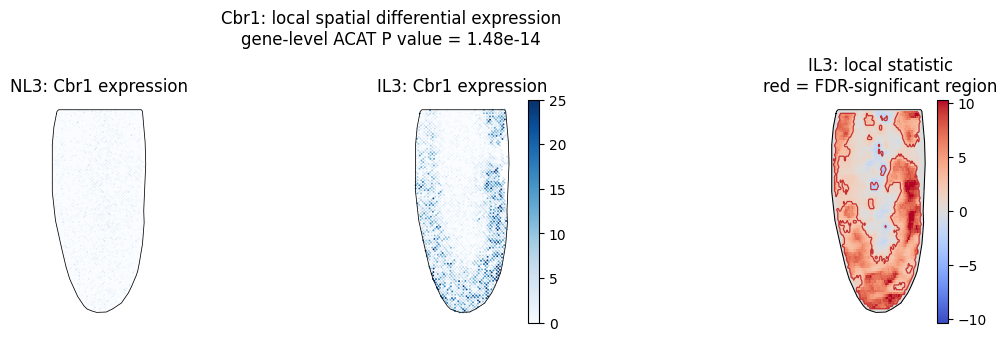

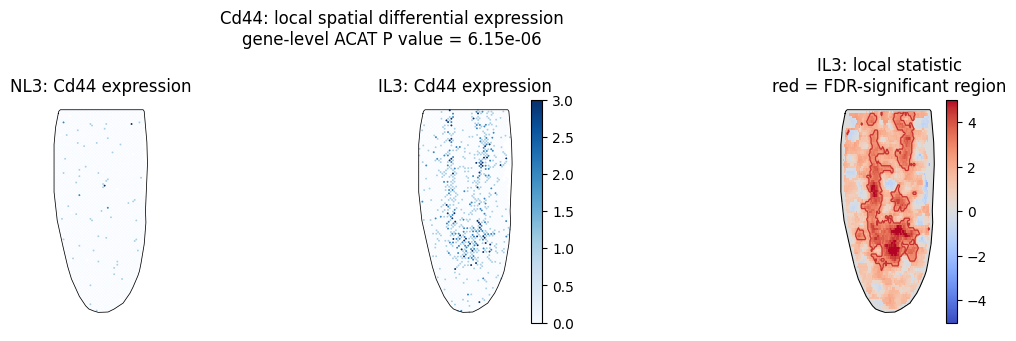

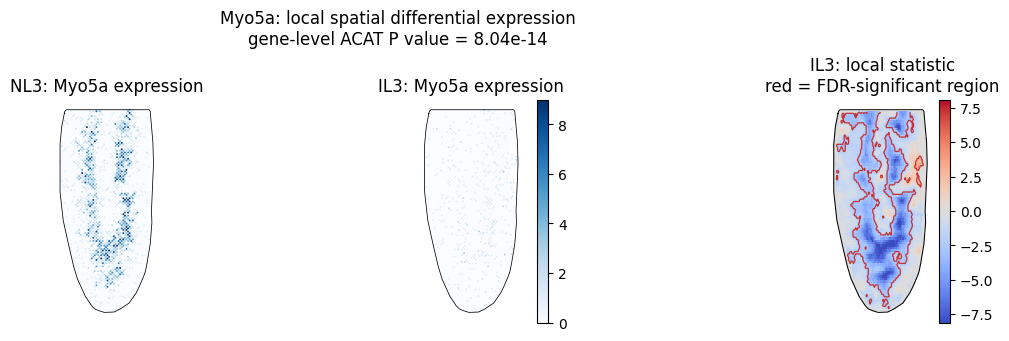

In [6]:
summary_rows = []
for gene, fit in result.fits.items():
    gene_acat_pvalue = gene_level_acat_pvalue(result, gene)
    terrain = fit["terrain_data"]
    for query_id in terrain["time_ids"]:
        statistic = np.asarray(terrain["stat_by_time"][query_id], dtype=float)
        q_value = np.asarray(terrain["q_by_time"][query_id], dtype=float)
        significant = np.asarray(
            terrain["sig_mask_by_time"][query_id],
            dtype=bool,
        )
        summary_rows.append(
            {
                "gene": gene,
                "contrast": f"{query_id} - NL3",
                "gene-level ACAT P value": gene_acat_pvalue,
                "significant grid locations": int(significant.sum()),
                "minimum q-value": float(np.nanmin(q_value)),
                "median |t|": float(np.nanmedian(np.abs(statistic))),
            }
        )

display(pd.DataFrame(summary_rows))

for gene in genes_to_test:
    figure = plot_local_result(
        result,
        gene,
        show_expression=True,
        invert_y=False,
    )
    plt.show()


## 7. Interpretation and extensions

This example demonstrates the complete alignment-output $\rightarrow$ shared-grid inference $\rightarrow$ local DE maps $\rightarrow$ gene-level ACAT P value handoff. It is a single matched-section NL3-versus-IL3 comparison and should not be interpreted as replicate-level population inference. The packaged coordinates make the alignment-to-inference handoff reproducible, while `SPALIGNDE_ALIGNMENT_DIR` allows users to repeat the same workflow with their own standardized alignment output. Users with reliable cell-type annotations can add a `celltype` column and enable `cell_type_adjustment=True`. Multiple query sections can be analyzed against one reference and summarized with gene-level ACAT or trajectory clustering.
